In [1]:
import numpy as np
from PRGDS_Interval_Tensor import PRGDS_tensor
from tqdm.auto import tqdm
import torch
import matplotlib.pyplot as plt

In [2]:
test = np.load('/home/HuangRui/PointProcess/NodeGroup/data/icews_tensor_preprocessed_22810010013.npz', allow_pickle=True)

In [3]:
burnin = 60
maxiter = 20 
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.,
'epsilon_lam': 1.,
'stationary': True,
'data' : torch.tensor(test['data'][:120]),
'K' : 50, # latent components
'S' : 60, # sub-intervals
'parallel' : True
}

model = PRGDS_tensor(**params)
expectation_collection = []
forecast_collection = []
transition_collection = []

for iter in tqdm(range(burnin+maxiter)):
    model.sample_n()
    model.sample_h()
    model.sample_the()
    model.sample_lam()
    model.sample_delt()
    model.sample_g()
    model.sample_gam()
    model.sample_beta()
    model.sample_phi()
    model.sample_pi()

    if iter+1 > burnin:
        transition_collection.append(model.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 113.6982 seconds
sample_h took 2.6674 seconds
sample_the took 0.0019 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0174 seconds
sample_g took 0.0032 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 5.6071 seconds
sample_pi took 0.4600 seconds
sample_n took 108.5739 seconds
sample_h took 2.9362 seconds
sample_the took 0.0019 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0195 seconds
sample_g took 0.0032 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 6.9303 seconds
sample_pi took 0.3100 seconds
sample_n took 99.8129 seconds
sample_h took 2.5880 seconds
sample_the took 0.0024 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0187 seconds
sample_g took 0.0025 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 6.3908 seconds
sample_pi took 0.3506 seconds
sample_n took 98.7676 seconds
sample_h took 3.1878 seconds
sample_the took 0.001

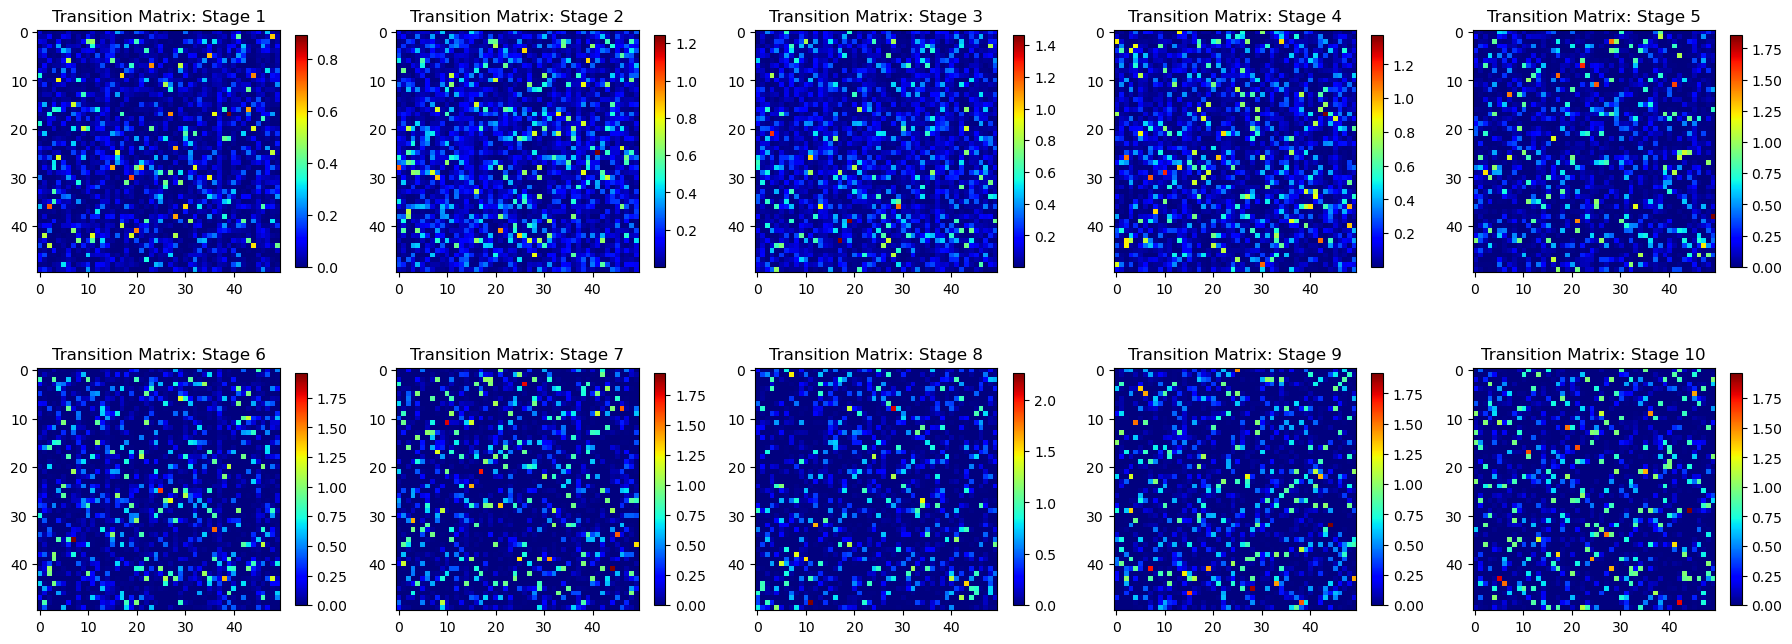

In [6]:
%matplotlib inline
transition_steady = torch.stack(transition_collection) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(2, 5, figsize=(18,7))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[3:6], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*6:i*6+6], axis = 0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

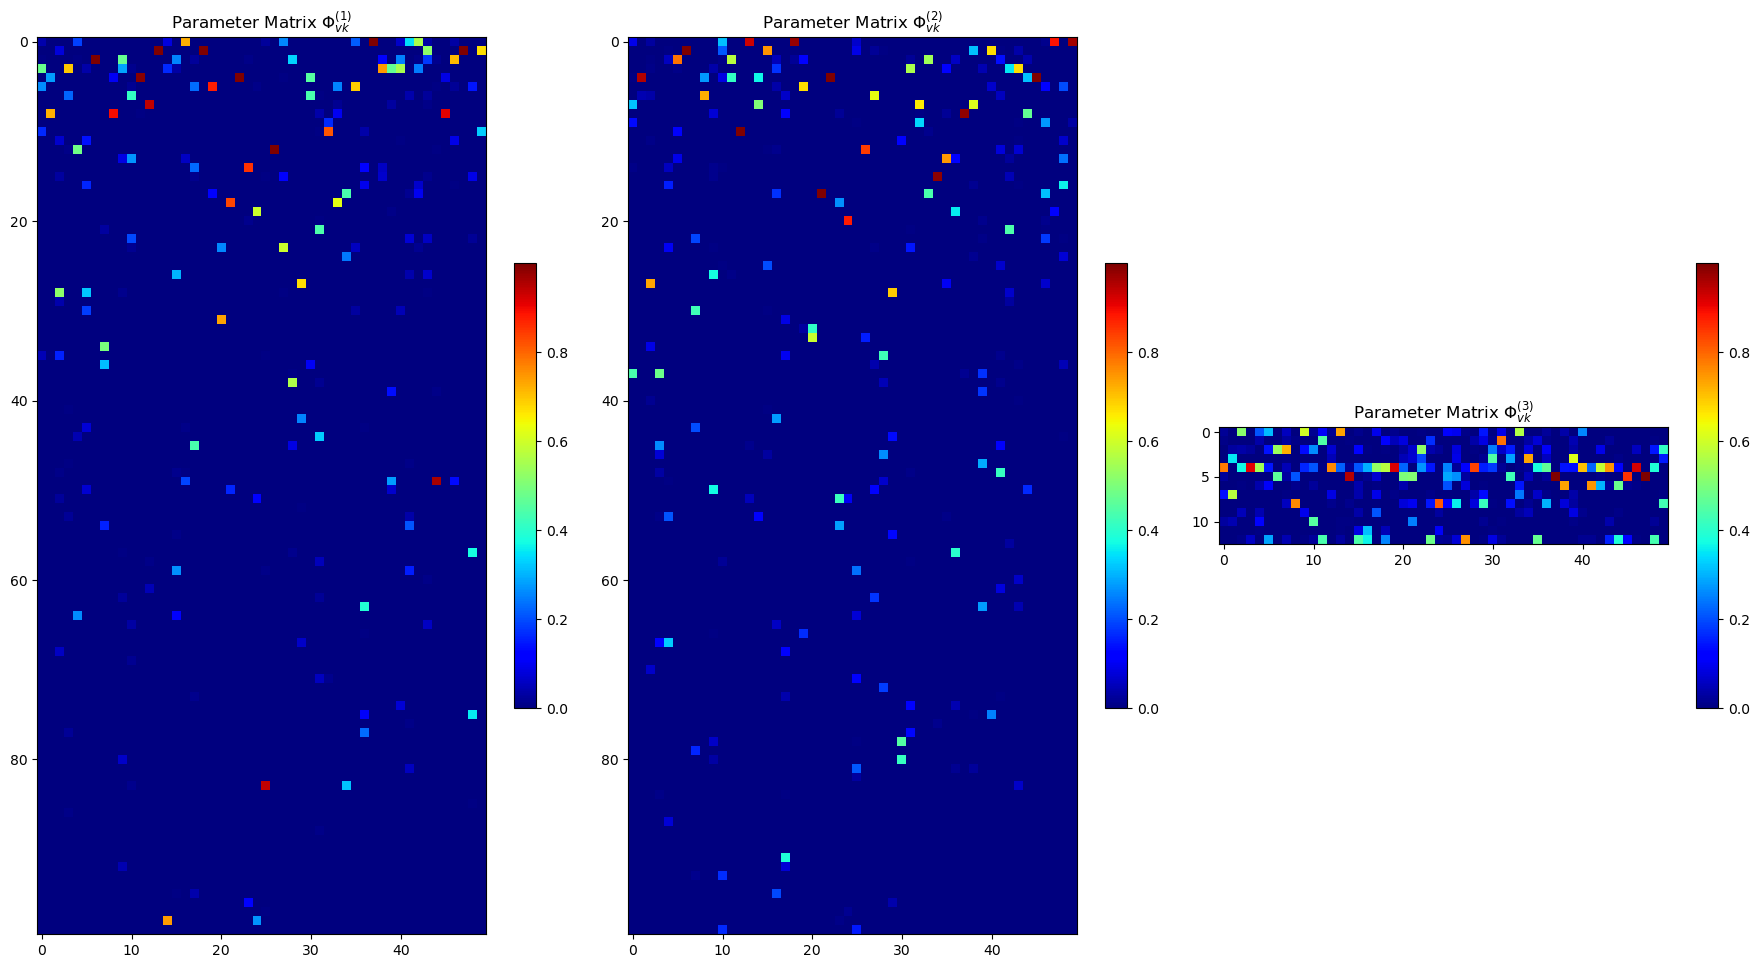

In [8]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (18, 12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        im = ax.imshow(model.phi[0], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(1)}$')
        cbar = plt.colorbar(im ,ax = ax, shrink = 0.38)
    elif i == 1:
        im = ax.imshow(model.phi[1], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(2)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
    elif i == 2:
        im = ax.imshow(model.phi[2], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(3)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
plt.tight_layout()
plt.show()

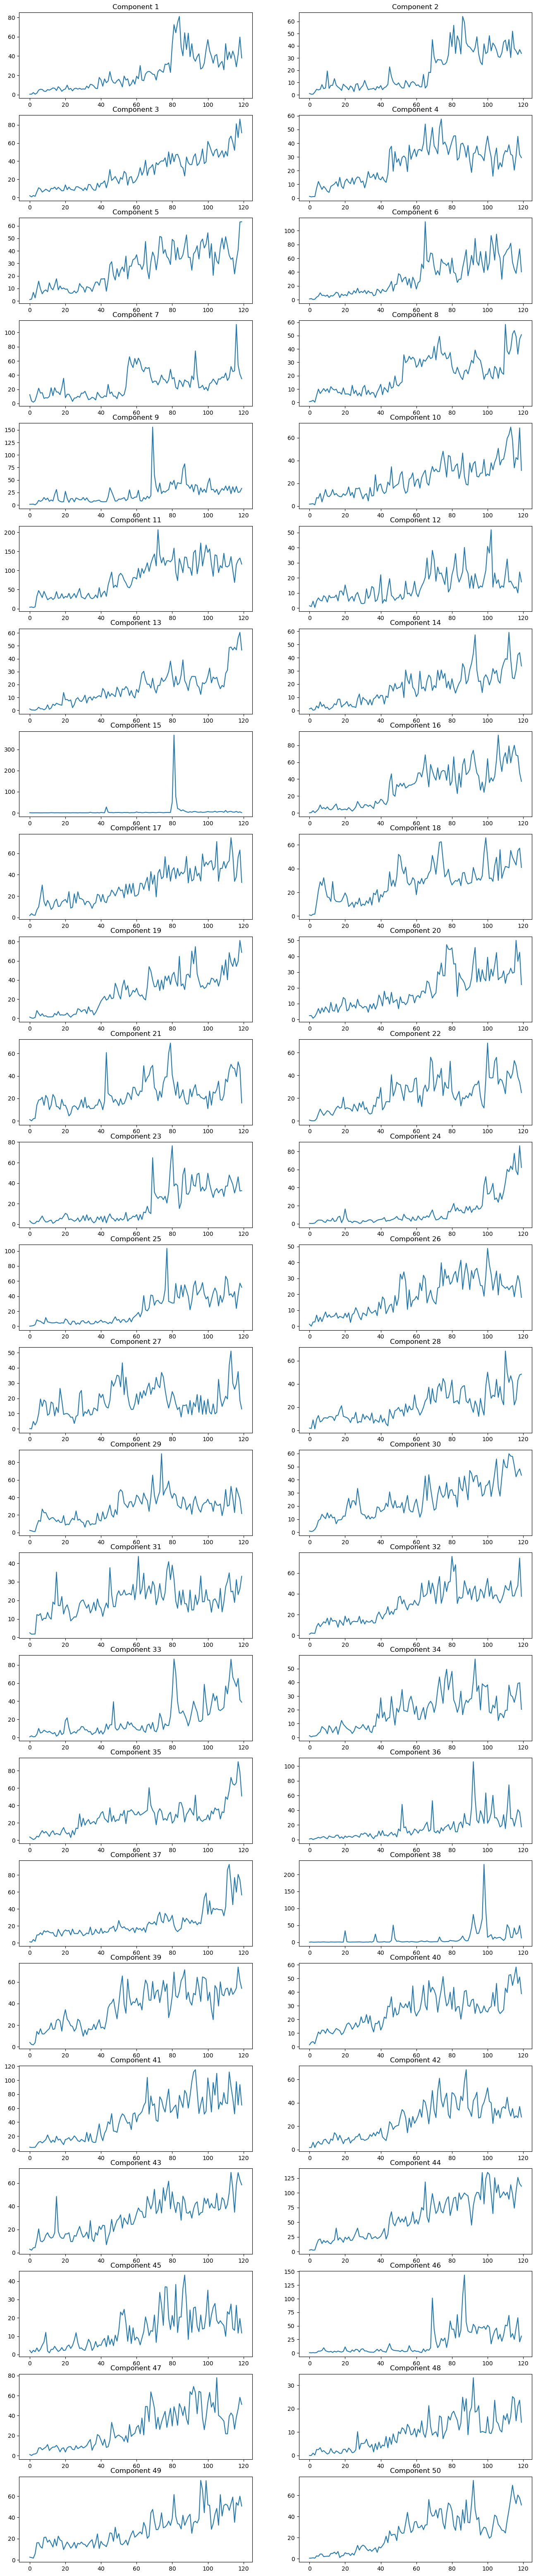

In [9]:
%matplotlib inline
fig, axs = plt.subplots(25, 2, figsize = (16,80))
for i, ax in enumerate(axs.flatten()):
    ax.plot(model.the.T[i])
    ax.set_title('Component {}'.format(i+1))
plt.show()

# Collect expectation of each iteration to compute negative log likelihood

In [24]:
import numpy as np
from PRGDS_Interval_Tensor import PRGDS_tensor
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
from scipy.stats import poisson

In [2]:
test = np.load('/home/HuangRui/PointProcess/NodeGroup/data/icews_tensor_preprocessed_33610010013.npz', allow_pickle=True)

In [3]:
burnin = 60
maxiter = 40
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.,
'epsilon_lam': 1.,
'stationary': True,
'data' : torch.tensor(test['data'][:108]),
'K' : 50, # latent components
'S' : 1, # sub-intervals
'parallel' : True
}

model = PRGDS_tensor(**params)
expectation_collection = []
transition_collection = []

for iter in tqdm(range(burnin+maxiter)):
    model.sample_n()
    model.sample_h()
    model.sample_the()
    model.sample_lam()
    model.sample_delt()
    model.sample_g()
    model.sample_gam()
    model.sample_beta()
    model.sample_phi()
    model.sample_pi()

    # compute expectation of training data
    part1 = torch.einsum('ik, jk, lk -> ijlk', model.phi[0], model.phi[1], model.phi[2])
    part2 = torch.einsum('k, tk, t -> kt', model.lam, model.the, model.delt)
    expectation = torch.einsum('ijlk, kt -> ijlt', part1, part2)
    expectation_collection.append(expectation.clone())

    if iter > burnin:
        transition_collection.append(model.pi.clone())

  0%|          | 0/100 [00:00<?, ?it/s]

sample_n took 98.2352 seconds
sample_h took 2.6798 seconds
sample_the took 0.0031 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0172 seconds
sample_g took 0.0035 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 5.1358 seconds
sample_pi took 0.0063 seconds
sample_n took 96.6927 seconds
sample_h took 2.7494 seconds
sample_the took 0.0022 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0220 seconds
sample_g took 0.0033 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 6.2623 seconds
sample_pi took 0.0064 seconds
sample_n took 93.8901 seconds
sample_h took 3.1383 seconds
sample_the took 0.0023 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0217 seconds
sample_g took 0.0041 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 4.9513 seconds
sample_pi took 0.0060 seconds
sample_n took 95.5646 seconds
sample_h took 2.7590 seconds
sample_the took 0.0016 

In [7]:
np.save('expectation_collection_prgds_100iter.npy', torch.stack(expectation_collection))

In [8]:
expectation_collection = np.load('expectation_collection_prgds_100iter.npy')

In [25]:
# compute negative log likelihood
negll_collection = []
truth_count = torch.tensor(test['data'][:108]).permute(1,2,3,0)
for expectation in tqdm(expectation_collection):
    pmf = poisson.pmf(truth_count, expectation) 
    negll = np.mean(-np.log(pmf + 1e-32))
    negll_collection.append(np.copy(negll))

100%|██████████| 100/100 [04:34<00:00,  2.75s/it]


In [55]:
base_negll_collection = np.ones(len(negll_collection)) * np.mean(-np.log(poisson.pmf(truth_count, 0) + 1e-32))

[array(0.37679401), array(0.59933402), array(0.63310615), array(0.63242842), array(0.63536373), array(0.63031552), array(0.64399759), array(0.6465765), array(0.63996394), array(0.6438707)]


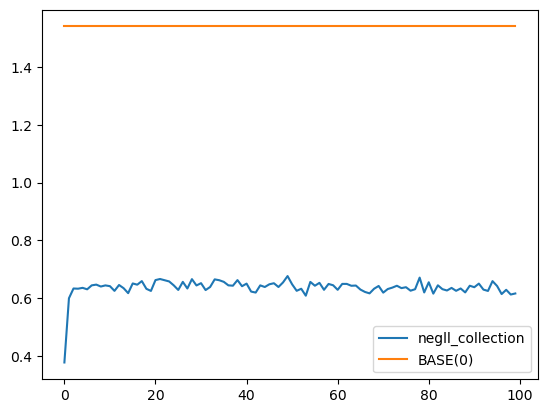

In [37]:
print(negll_collection[:10])
plt.plot(negll_collection, label = 'negll_collection')
plt.plot(base_negll_collection, label = 'BASE(0)')
plt.legend()
plt.show()

In [29]:
# compute mean pmf
pmf_collection = []
truth_count = torch.tensor(test['data'][:108]).permute(1,2,3,0)
for expectation in tqdm(expectation_collection):
    pmf = poisson.pmf(truth_count, expectation) 
    pmf = np.mean(pmf)
    pmf_collection.append(np.copy(pmf))

100%|██████████| 100/100 [02:33<00:00,  1.53s/it]


In [41]:
base_pmf_collection = np.ones(len(pmf_collection)) * np.mean(poisson.pmf(truth_count, 0))

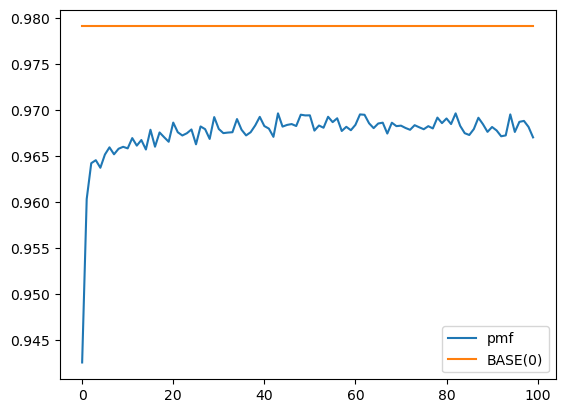

In [42]:
plt.plot(pmf_collection, label = 'pmf')
plt.plot(base_pmf_collection, label = 'BASE(0)')
plt.legend()
plt.show()

In [32]:
neglog_pmf_collection = -np.log(pmf_collection)
base_neglog_pmf_collection = np.ones(len(pmf_collection)) * (-np.log(np.mean(poisson.pmf(truth_count, 0))))

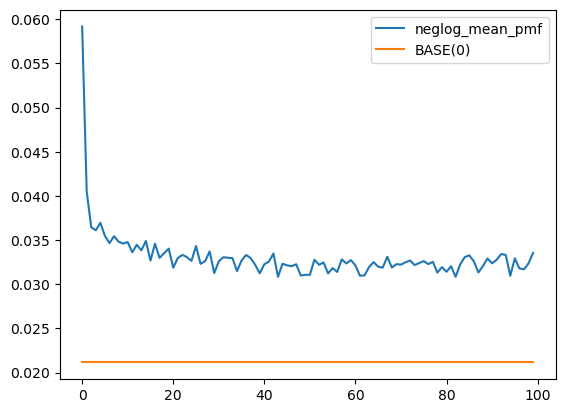

In [34]:
plt.plot(neglog_pmf_collection, label = 'neglog_mean_pmf')
plt.plot(base_neglog_pmf_collection, label = 'BASE(0)')
plt.legend()
plt.show()

为什么先求mean pmf在-log 和 先-log在mean的结果是相反的呢？

In [9]:
# compute MRE and MAE
def mae(truth, pred):
    return np.abs(truth-pred).mean()

def mre(truth, pred):
    return (np.abs(truth - pred) / (truth + 1)).mean()

mre_collection = []
mae_collection = []
truth_count = torch.tensor(test['data'][:108]).permute(1,2,3,0)
for expectation in tqdm(expectation_collection):
    mre_collection.append(mre(truth_count, expectation))
    mae_collection.append(mae(truth_count, expectation))
    
base_mre_collection = np.ones(len(mre_collection)) * mre(truth_count, 0 )
base_mae_collection = np.ones(len(mae_collection)) * mae(truth_count, 0)

  0%|          | 0/100 [00:00<?, ?it/s]

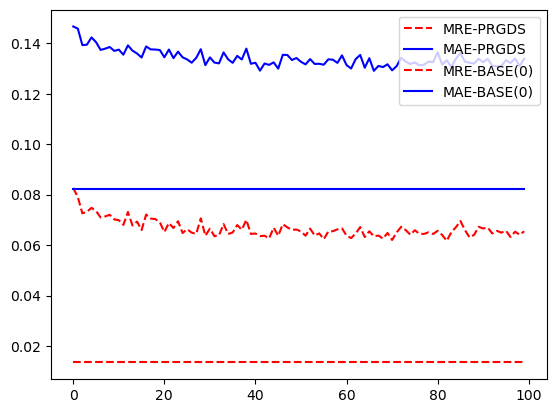

In [22]:
%matplotlib inline
plt.plot(mre_collection, color = 'red', linestyle = '--', label = 'MRE-PRGDS')
plt.plot(mae_collection, color = 'blue', label = 'MAE-PRGDS')
plt.plot(base_mre_collection, color = 'red', linestyle = '--', label = 'MRE-BASE(0)')
plt.plot(base_mae_collection, color = 'blue', label = 'MAE-BASE(0)')
plt.legend()
plt.show()

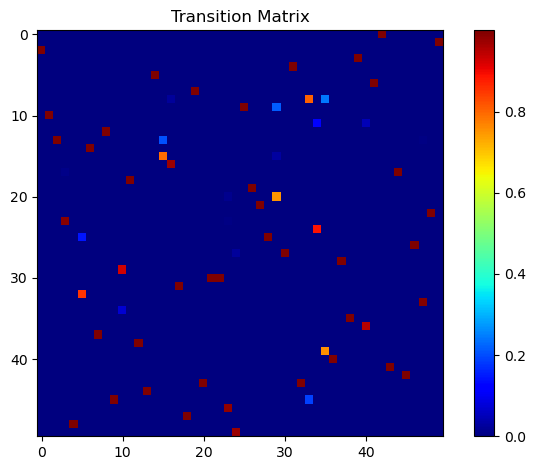

In [58]:
%matplotlib inline
transition_steady = torch.stack(transition_collection) 
transition_mean = torch.mean(transition_steady, axis = 0)
plt.imshow(transition_mean[0], cmap='jet')
plt.title(f'Transition Matrix')
# Add colorbar to each subplot
plt.colorbar()
plt.tight_layout()
plt.show()

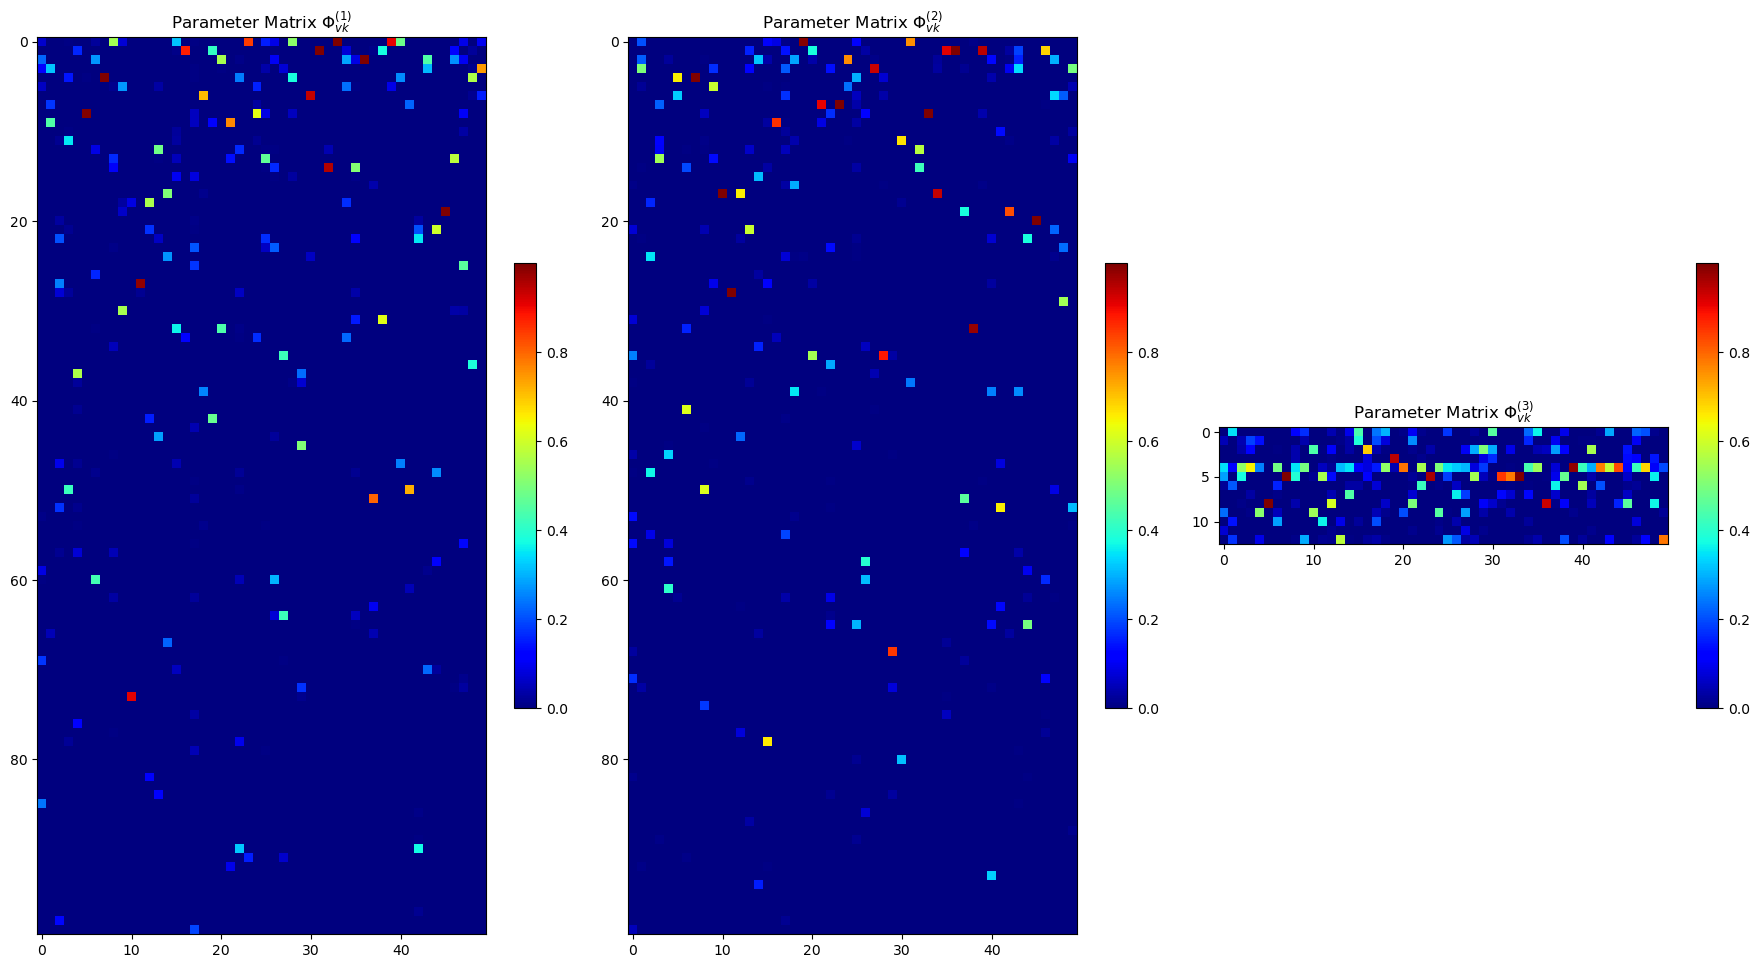

In [59]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (18, 12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        im = ax.imshow(model.phi[0], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(1)}$')
        cbar = plt.colorbar(im ,ax = ax, shrink = 0.38)
    elif i == 1:
        im = ax.imshow(model.phi[1], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(2)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
    elif i == 2:
        im = ax.imshow(model.phi[2], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(3)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
plt.tight_layout()
plt.show()

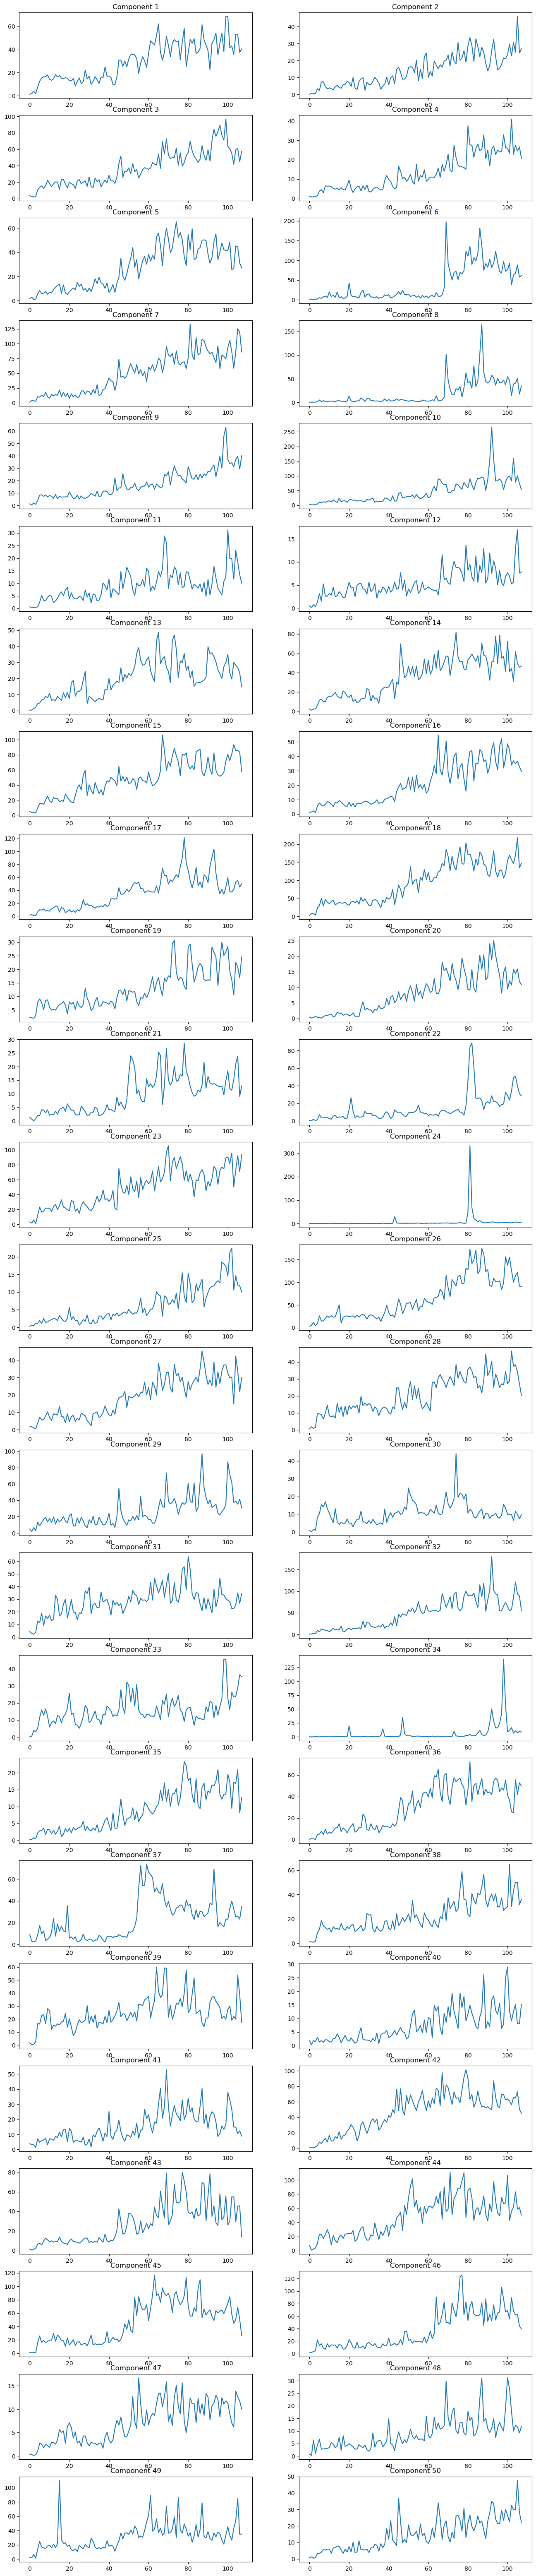

In [36]:
%matplotlib inline
fig, axs = plt.subplots(25, 2, figsize = (16,80))
for i, ax in enumerate(axs.flatten()):
    ax.plot(model.the.T[i])
    ax.set_title('Component {}'.format(i+1))
plt.show()